## Importación de librerías

In [1]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

%matplotlib inline

sns.set_theme()


## Carga, agregación a 90 días y purga de datos sensibles

In [2]:
# 1. Cargar datos
vle_df = pd.read_csv('./../../../dataset/oulad/studentVle.csv')
info_df = pd.read_csv('./../../../dataset/oulad/studentInfo.csv')

vle_90_days = vle_df[vle_df['date'] <= 90]
vle_agg = vle_90_days.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    total_clicks=('sum_click', 'sum'),
    mean_clicks=('sum_click', 'mean'),
    active_days=('date', 'nunique')
).reset_index()

vle_agg.fillna(0, inplace=True)

# 3. Excluir datos sensibles
sensitive_columns = ['gender', 'disability', 'age_band', 'imd_band', 'region']
info_clean = info_df.drop(columns=sensitive_columns)

## Cruce de datos y creación del Target

In [3]:

df_merged = pd.merge(info_clean, vle_agg, on=['id_student', 'code_module', 'code_presentation'], how='inner')

# 2. Definir Agotamiento (Withdrawn = 1, Resto = 0)
df_merged['target_burnout'] = df_merged['final_result'].apply(lambda x: 1 if x == 'Withdrawn' else 0)

# Limpiar columnas innecesarias para el modelo (OJO: ya no borramos 'code_presentation' aquí)
df_merged = df_merged.drop(columns=['final_result', 'id_student'])

## Partición por cursos

In [4]:
df_train = df_merged[df_merged['code_presentation'].str.contains('2013')].copy()

df_test = df_merged[df_merged['code_presentation'].str.contains('2014')].copy()

columnas_a_borrar = ['code_module', 'code_presentation']

# Separar matriz de características (X) y variable objetivo (y)
X_train = df_train.drop(columns=columnas_a_borrar + ['target_burnout'], errors='ignore')
y_train = df_train['target_burnout']

X_test = df_test.drop(columns=columnas_a_borrar + ['target_burnout'], errors='ignore')
y_test = df_test['target_burnout']

print(f"Alumnos en Histórico (Train 2013): {len(X_train)}")
print(f"Alumnos Nuevos (Test 2014): {len(X_test)}")

Alumnos en Histórico (Train 2013): 12192
Alumnos Nuevos (Test 2014): 16966


## Construcción y Entrenamiento del Pipeline

In [5]:


# Definición de columnas
cat_cols = ['highest_education']
num_cols = ['num_of_prev_attempts', 'studied_credits', 'total_clicks', 'mean_clicks', 'active_days']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', class_weight='balanced', random_state=42))
])

# Entrenar
svm_pipeline.fit(X_train, y_train)

# Generar predicciones
y_pred = svm_pipeline.predict(X_test)

## Evaluación y Gráficas de Rendimiento

--- REPORTE DE CLASIFICACIÓN DETALLADO (SVM) ---
              precision    recall  f1-score   support

           0       0.85      0.69      0.76     12412
           1       0.44      0.66      0.53      4554

    accuracy                           0.68     16966
   macro avg       0.64      0.68      0.64     16966
weighted avg       0.74      0.68      0.70     16966



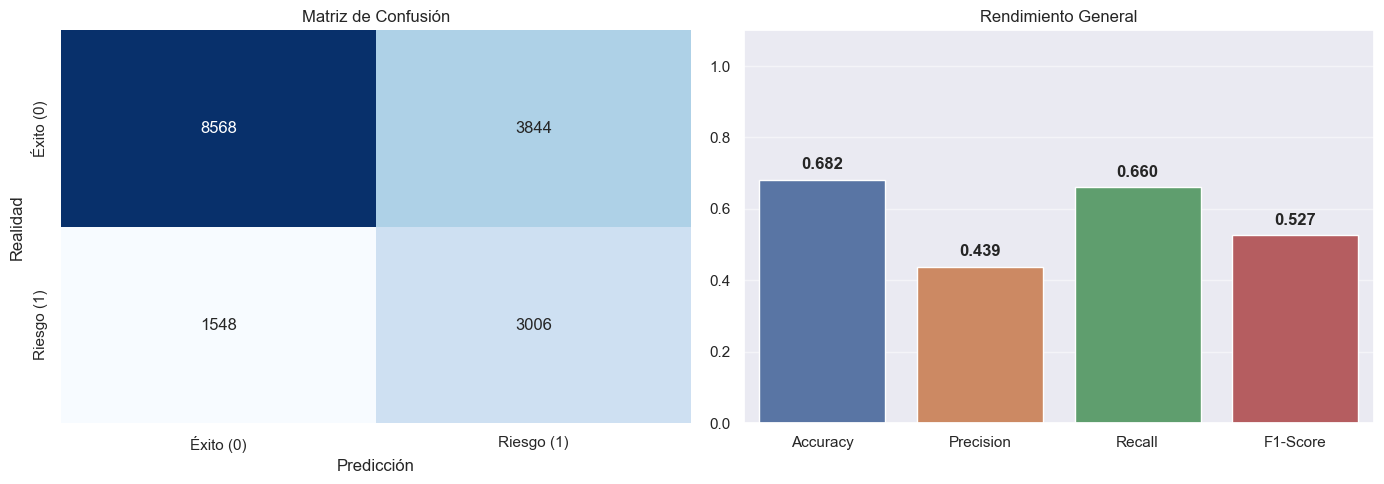

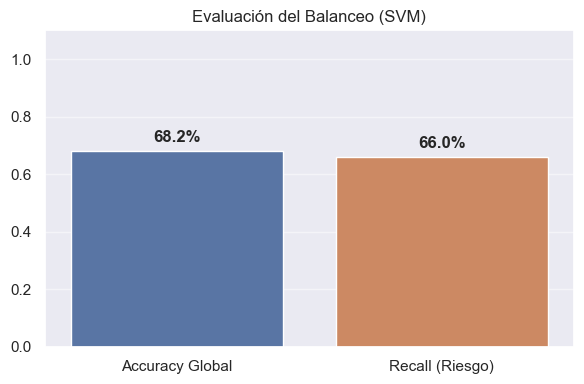

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# CÁLCULO DE MÉTRICAS Y REPORTE
# ==========================================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("--- REPORTE DE CLASIFICACIÓN DETALLADO (SVM) ---")
print(classification_report(y_test, y_pred, zero_division=0))

# ==========================================
# GRÁFICOS: MÉTRICAS Y MATRIZ DE CONFUSIÓN
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=['Éxito (0)', 'Riesgo (1)'],
            yticklabels=['Éxito (0)', 'Riesgo (1)'])
ax1.set_title('Matriz de Confusión')
ax1.set_xlabel('Predicción')
ax1.set_ylabel('Realidad')

# Subplot 2: Métricas Habituales
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [acc, prec, rec, f1]
sns.barplot(x=metrics_names, y=metrics_values, hue=metrics_names, legend=False, ax=ax2)
ax2.set_title('Rendimiento General')
ax2.set_ylim(0, 1.1)

for i, v in enumerate(metrics_values):
    ax2.text(i, v + 0.02, f"{v:.3f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# GRÁFICO: Accuracy vs Recall Minoritario
# ==========================================
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
burnout_recall = report_dict['1']['recall']

plt.figure(figsize=(6, 4))
metric_names_comp = ['Accuracy Global', 'Recall (Riesgo)']
metric_values_comp = [acc, burnout_recall]

ax3 = sns.barplot(x=metric_names_comp, y=metric_values_comp, hue=metric_names_comp, legend=False)
plt.title('Evaluación del Balanceo (SVM)')
plt.ylim(0, 1.1)

for i, v in enumerate(metric_values_comp):
    ax3.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Grid search

In [7]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import numpy as np

# 1. Definición del Pipeline para SVM
# IMPORTANTE: probability=True es obligatorio para poder extraer probabilidades después
svm_pipeline_grid = Pipeline(steps=[
    ('preprocessor', preprocessor), # Reutilizamos tu preprocesador de las celdas anteriores
    ('classifier', SVC(probability=True, random_state=42))
])

# 2. Configuración del espacio de búsqueda
# C: Penalización del error (regularización)
# kernel: Tipo de frontera (linear para relaciones directas, rbf para complejas)
param_grid_svm = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__class_weight': [None, 'balanced', {0: 1, 1: 3}]
}

print("Iniciando Grid Search para SVM...")
print("Nota: Este proceso puede tardar varios minutos dependiendo del volumen de datos.")

# 3. Ejecución de la búsqueda optimizando F1-Score
grid_search_svm = GridSearchCV(
    estimator=svm_pipeline_grid,
    param_grid=param_grid_svm,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search_svm.fit(X_train, y_train)

# 4. Resultados
print("\n" + "="*50)
print("¡BÚSQUEDA DE SVM FINALIZADA!")
print("Mejores parámetros encontrados:")
for param, value in grid_search_svm.best_params_.items():
    print(f" - {param.replace('classifier__', '')}: {value}")
print("="*50)

# Extraemos las probabilidades del mejor modelo para el siguiente paso
mejor_modelo_svm = grid_search_svm.best_estimator_
y_probs_svm = mejor_modelo_svm.predict_proba(X_test)[:, 1]

Iniciando Grid Search para SVM...
Nota: Este proceso puede tardar varios minutos dependiendo del volumen de datos.
Fitting 3 folds for each of 18 candidates, totalling 54 fits

¡BÚSQUEDA DE SVM FINALIZADA!
Mejores parámetros encontrados:
 - C: 0.1
 - class_weight: balanced
 - kernel: linear


In [8]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

print("\n" + "=" * 65)
print(" BARRIDO DIFERENCIAL DE UMBRALES (SVM)")
print("=" * 65)
print(f"{'Umbral':<8} | {'Accuracy Global':<18} | {'Recall (Riesgo)':<18} | {'Precisión (Riesgo)':<18}")
print("-" * 65)

# Probamos con saltos del 2%
umbrales_prueba = np.arange(0.30, 0.72, 0.02)

for u in umbrales_prueba:
    # Aplicamos el umbral a las probabilidades de SVM
    y_pred_temp = (y_probs_svm >= u).astype(int)

    acc = accuracy_score(y_test, y_pred_temp)
    rec = recall_score(y_test, y_pred_temp, zero_division=0)
    prec = precision_score(y_test, y_pred_temp, zero_division=0)

    print(f"{u:.2f}     | {acc*100:>5.1f}%             | {rec*100:>5.1f}%             | {prec*100:>5.1f}%")


 BARRIDO DIFERENCIAL DE UMBRALES (SVM)
Umbral   | Accuracy Global    | Recall (Riesgo)    | Precisión (Riesgo)
-----------------------------------------------------------------
0.30     |  73.8%             |  46.6%             |  51.3%
0.32     |  74.5%             |  40.1%             |  53.4%
0.34     |  75.3%             |  35.4%             |  56.2%
0.36     |  75.5%             |  30.0%             |  58.6%
0.38     |  75.7%             |  24.9%             |  61.9%
0.40     |  75.6%             |  20.4%             |  64.3%
0.42     |  75.4%             |  16.4%             |  66.6%
0.44     |  75.0%             |  13.1%             |  68.4%
0.46     |  74.6%             |  10.5%             |  68.0%
0.48     |  74.5%             |   8.8%             |  69.8%
0.50     |  74.3%             |   7.0%             |  73.0%
0.52     |  74.2%             |   5.9%             |  75.3%
0.54     |  74.0%             |   4.3%             |  77.6%
0.56     |  73.8%             |   3.5%    